# Ecom Fraud Shield
Generate Data → EDA → Features → Train → Compare → Best Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fraud import generate_data, save_data, load_data, build_features, train, threshold_summary, FEATURE_COLS


c:\Users\A\Desktop\Data Science\fraud_detect\fraud-detect\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251
c:\Users\A\Desktop\Data Science\fraud_detect\fraud-detect\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generate Synthetic E-Commerce Data

In [2]:
# Generate and save — only need to run this once
df = generate_data(n_samples=100000, fraud_rate=0.013)
save_data(df, 'data/raw/ecom_transactions.csv')
df.head()

2026-03-13 17:44:48,438 - INFO - Generated 100,000 rows | Fraud: 1.30%
2026-03-13 17:44:49,374 - INFO - Saved to data/raw/ecom_transactions.csv


,amount,payment_method,merchant_category,device_os,hour_of_day,is_new_account,device_changed,location_changed,failed_attempts,txn_count_24hr,amount_vs_avg,ip_risk_score,is_international,time_since_last_txn_mins,is_fraud
0,2623.815654,upi,electronics,android,16,0,1,0,0,2,1.871384,0.115322,0,130.231146,0
1,19716.518593,upi,grocery,android,13,0,1,0,0,4,1.250007,0.120957,0,34.274136,0
2,8195.021900,upi,food,web,14,0,1,0,0,0,0.745271,0.223430,0,120.757314,0
3,156.118216,upi,fashion,android,20,1,0,0,3,3,0.949798,0.194156,0,68.615949,0
4,2687.158343,upi,electronics,ios,11,0,0,0,0,1,0.684159,0.231740,0,161.143269,0


## 2. EDA

In [3]:
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print(f'\nFraud rate: {df.is_fraud.mean():.2%}')
print('\nFraud counts:\n', df.is_fraud.value_counts())

Shape: (100000, 15)

Missing values:
 amount                      0
payment_method              0
merchant_category           0
device_os                   0
hour_of_day                 0
is_new_account              0
device_changed              0
location_changed            0
failed_attempts             0
txn_count_24hr              0
amount_vs_avg               0
ip_risk_score               0
is_international            0
time_since_last_txn_mins    0
is_fraud                    0
dtype: int64

Fraud rate: 1.30%

Fraud counts:
 is_fraud
0    98700
1     1300
Name: count, dtype: int64


In [4]:
# Fraud rate by payment method
print('Fraud rate by payment method:')
print(df.groupby('payment_method')['is_fraud'].mean().sort_values(ascending=False))

print('\nFraud rate by merchant category:')
print(df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False))

Fraud rate by payment method:
payment_method
credit_card    0.026218
debit_card     0.012385
wallet         0.007231
upi            0.006417
Name: is_fraud, dtype: float64

Fraud rate by merchant category:
merchant_category
electronics    0.035025
travel         0.034667
pharmacy       0.012596
food           0.007202
fashion        0.005604
grocery        0.003301
Name: is_fraud, dtype: float64


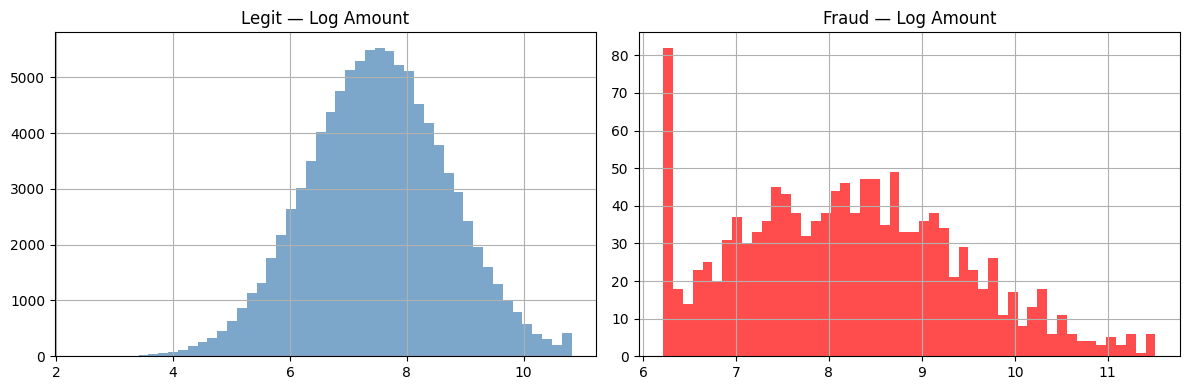

In [5]:
# Amount distribution — fraud vs legit
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[df.is_fraud==0]['amount'].apply(np.log1p).hist(bins=50, ax=ax[0], alpha=0.7, color='steelblue')
df[df.is_fraud==1]['amount'].apply(np.log1p).hist(bins=50, ax=ax[1], alpha=0.7, color='red')
ax[0].set_title('Legit — Log Amount')
ax[1].set_title('Fraud — Log Amount')
plt.tight_layout()
plt.show()

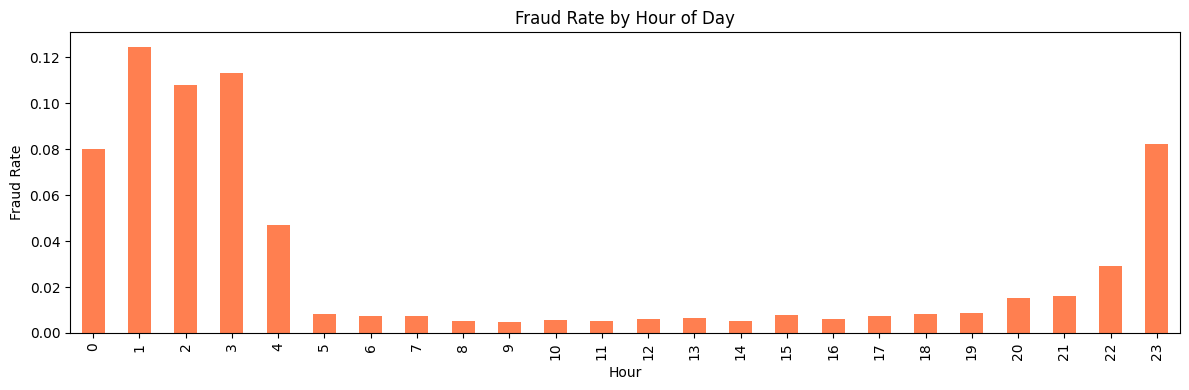

In [6]:
# Fraud by hour of day
fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].mean()
plt.figure(figsize=(12, 4))
fraud_by_hour.plot(kind='bar', color='coral')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [7]:
# Key fraud signals
print('Fraud rate — New Account:')
print(df.groupby('is_new_account')['is_fraud'].mean())

print('\nFraud rate — Device Changed:')
print(df.groupby('device_changed')['is_fraud'].mean())

print('\nFraud rate — Location Changed:')
print(df.groupby('location_changed')['is_fraud'].mean())

print('\nFraud rate — International:')
print(df.groupby('is_international')['is_fraud'].mean())

Fraud rate — New Account:
is_new_account
0    0.007733
1    0.069146
Name: is_fraud, dtype: float64

Fraud rate — Device Changed:
device_changed
0    0.006867
1    0.045956
Name: is_fraud, dtype: float64

Fraud rate — Location Changed:
location_changed
0    0.005869
1    0.051421
Name: is_fraud, dtype: float64

Fraud rate — International:
is_international
0    0.007486
1    0.051600
Name: is_fraud, dtype: float64


## 3. Feature Engineering

In [8]:
df_feat = build_features(df)
print('Features used for training:')
print(FEATURE_COLS)

Features used for training:
['amount_log', 'payment_method_encoded', 'merchant_category_encoded', 'device_os_encoded', 'hour_of_day', 'is_new_account', 'device_changed', 'location_changed', 'failed_attempts', 'txn_count_24hr', 'amount_vs_avg', 'ip_risk_score', 'is_international', 'time_since_last_txn_mins', 'is_high_risk_merchant', 'is_card_payment', 'is_late_night', 'is_high_value', 'high_velocity', 'combined_risk']


In [9]:
import mlflow
mlflow.set_tracking_uri("file:./mlruns")

## 4. Train All Models with CV

In [10]:
# Optional: mlflow ui --port 5000 in a separate terminal
best_model, best_name, X_test, y_test, y_prob, all_results = train(df)
print(f'\nBest model: {best_name}')

2026-03-13 17:45:04,497 - INFO - Training LogisticRegression...
2026-03-13 17:48:02,723 - INFO -   CV: 0.9920 ± 0.0008 | Test AUC: 0.9714 | Recall: 0.9692 | FPR: 0.0050
2026-03-13 17:48:03,373 - INFO - Training DecisionTree...
2026-03-13 17:48:10,473 - INFO -   CV: 0.9723 ± 0.0023 | Test AUC: 0.8562 | Recall: 0.9346 | FPR: 0.0128
2026-03-13 17:48:10,576 - INFO - Training RandomForest...
2026-03-13 17:49:57,026 - INFO -   CV: 0.9979 ± 0.0008 | Test AUC: 0.9589 | Recall: 0.7500 | FPR: 0.0002
2026-03-13 17:49:57,205 - INFO - Training GradientBoosting...
2026-03-13 17:56:47,078 - INFO -   CV: 0.9970 ± 0.0005 | Test AUC: 0.9583 | Recall: 0.8885 | FPR: 0.0009
2026-03-13 17:56:47,192 - INFO - Training XGBoost...
2026-03-13 17:57:04,803 - INFO -   CV: 0.9989 ± 0.0002 | Test AUC: 0.9647 | Recall: 0.9231 | FPR: 0.0013
2026-03-13 17:57:04,931 - INFO - Training LightGBM...
2026-03-13 17:57:26,143 - INFO -   CV: 0.9988 ± 0.0003 | Test AUC: 0.9602 | Recall: 0.9154 | FPR: 0.0015
2026-03-13 17:57:26,2


Best model: XGBoost


             Model  CV AUC-PR   CV Std  Test AUC-PR   Recall      FPR
           XGBoost   0.998894 0.000216     0.964666 0.923077 0.001266
          LightGBM   0.998809 0.000333     0.960212 0.915385 0.001469
      RandomForest   0.997854 0.000774     0.958851 0.750000 0.000152
  GradientBoosting   0.997007 0.000514     0.958349 0.888462 0.000912
LogisticRegression   0.991983 0.000785     0.971396 0.969231 0.004965
      DecisionTree   0.972345 0.002312     0.856200 0.934615 0.012817


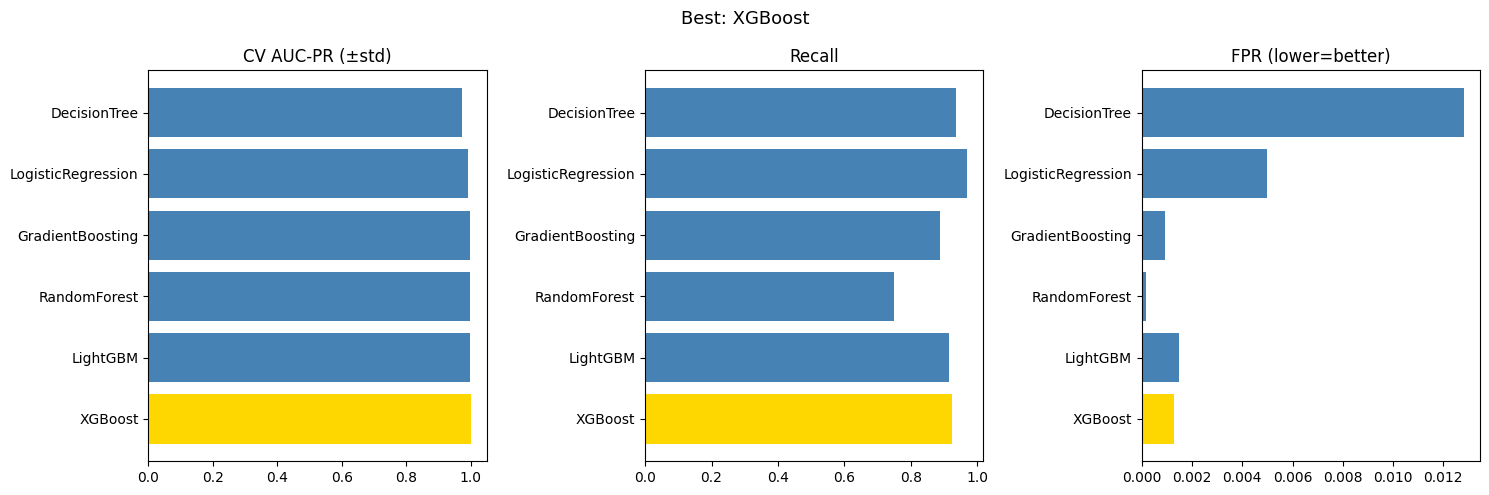

In [11]:
# Model comparison chart
comparison = pd.DataFrame([
    {'Model': n, 'CV AUC-PR': r['cv_mean'], 'CV Std': r['cv_std'], 
     'Test AUC-PR': r['test_auc'], 'Recall': r['recall'], 'FPR': r['fpr']}
    for n, r in all_results.items()
]).sort_values('CV AUC-PR', ascending=False)

print(comparison.to_string(index=False))

colors = ['gold' if n == best_name else 'steelblue' for n in comparison['Model']]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, ['CV AUC-PR', 'Recall', 'FPR'], 
                                  ['CV AUC-PR (±std)', 'Recall', 'FPR (lower=better)']):
    ax.barh(comparison['Model'], comparison[col], color=colors)
    ax.set_title(title)

plt.suptitle(f'Best: {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Threshold Tuning

In [12]:
# Use this table to tune .env thresholds
threshold_summary(y_test, y_prob)


 Threshold     Recall  Precision        FPR
      0.30      0.946      0.743      0.004
      0.40      0.946      0.796      0.003
      0.50      0.935      0.835      0.002
      0.60      0.931      0.864      0.002
      0.75      0.923      0.906      0.001
      0.85      0.915      0.933      0.001


## 6. SHAP — Why Does the Model Flag Fraud?

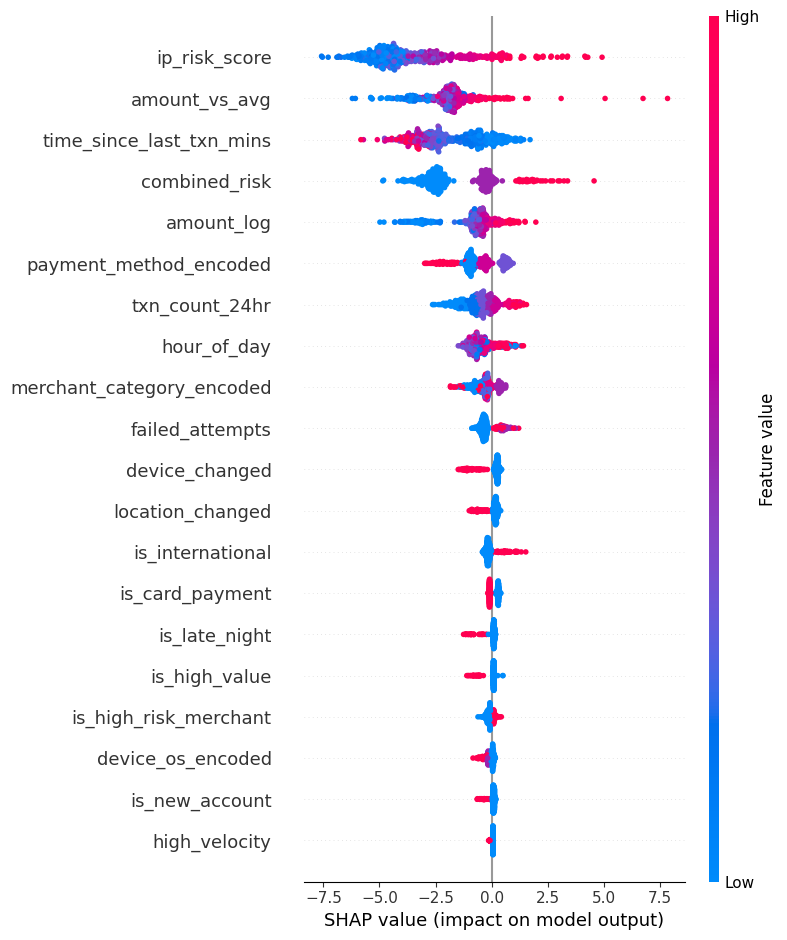

In [13]:
import shap
import numpy as np

explainer = shap.TreeExplainer(best_model)
shap_vals = explainer.shap_values(X_test[:500])

# Handle RandomForest — returns list
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

shap.summary_plot(shap_vals, X_test[:500], feature_names=np.array(FEATURE_COLS))